Import Library

In [2]:
import os  # For directory and file operations
import numpy as np  # For numerical operations
import random  # For random augmentation
from PIL import Image, ImageEnhance  # For image processing
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle


Load Datasets

In [3]:
train_dir = r'C:\Users\Apollo Gadget\Documents\Meem\Project\ML\Brain Tumor Detection Using Deep Learning\MRI Images\Training'
test_dir = r'C:\Users\Apollo Gadget\Documents\Meem\Project\ML\Brain Tumor Detection Using Deep Learning\MRI Images\Testing'


Load & Shuffle Training Data

In [4]:
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
    label_path = os.path.join(train_dir, label)
    if os.path.isdir(label_path):
        for image in os.listdir(label_path):
            train_paths.append(os.path.join(label_path, image))
            train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)


Load & Shuffle Testing Data

In [5]:
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    label_path = os.path.join(test_dir, label)
    if os.path.isdir(label_path):
        for image in os.listdir(label_path):
            test_paths.append(os.path.join(label_path, image))
            test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


Data Visualization

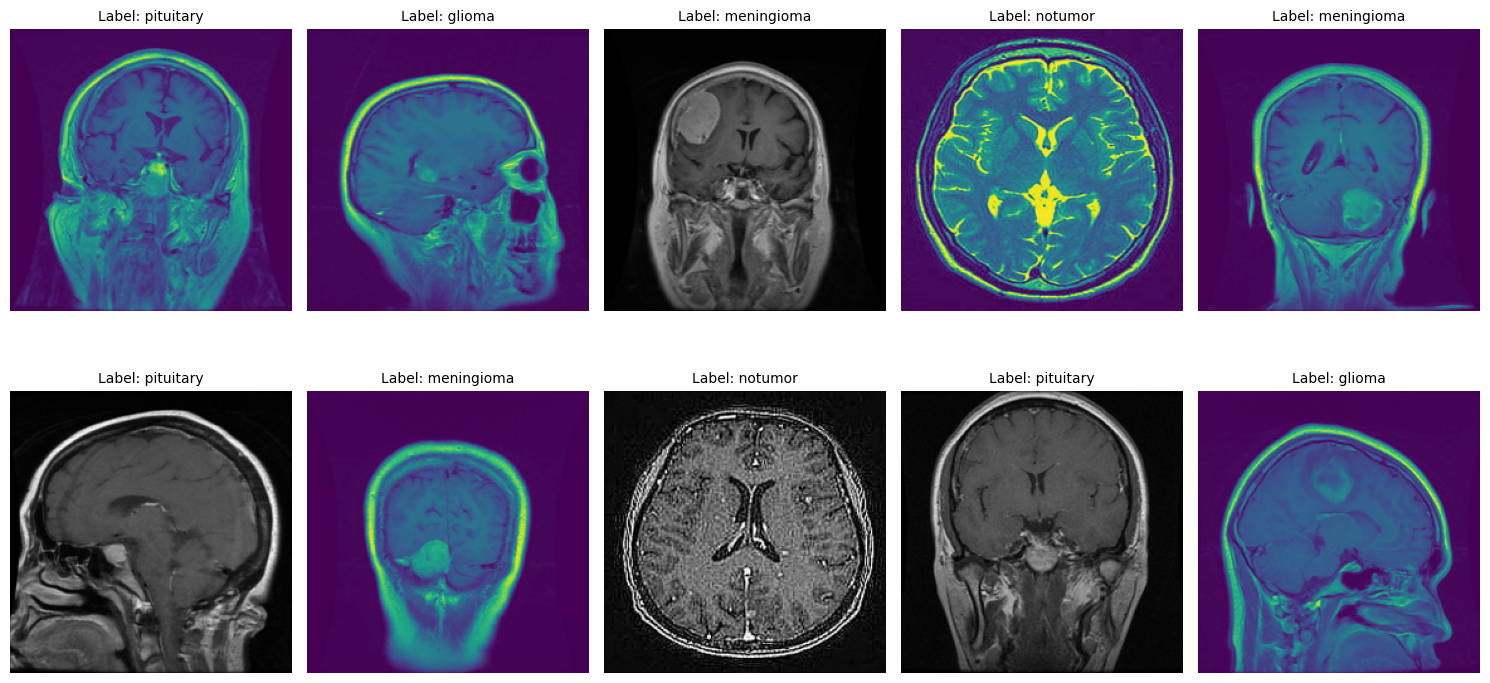

In [6]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

Image Preprocessing

In [7]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image


def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = np.array(image)   # FIX
        image = augment_image(image)
        images.append(image)
    return np.array(images)


def encode_label(labels):
    unique_labels = sorted(os.listdir(train_dir))  # FIX
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)


def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels


MODEL
WE ARE USING VGG16 FOR TRANSFER LEARNING.

In [8]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
285/285 [==============================] - 533s 2s/step - loss: 0.4537 - sparse_categorical_accuracy: 0.8281
Epoch 2/5
285/285 [==============================] - 478s 2s/step - loss: 0.2386 - sparse_categorical_accuracy: 0.9069
Epoch 3/5
285/285 [==============================] - 469s 2s/step - loss: 0.1390 - sparse_categorical_accuracy: 0.9471
Epoch 4/5
285/285 [==============================] - 466s 2s/step - loss: 0.1009 - sparse_categorical_accuracy: 0.9626
Epoch 5/5
285/285 [==============================] - 463s 2s/step - loss: 0.0690 - sparse_categorical_accuracy: 0.9736


Train and Val Plots

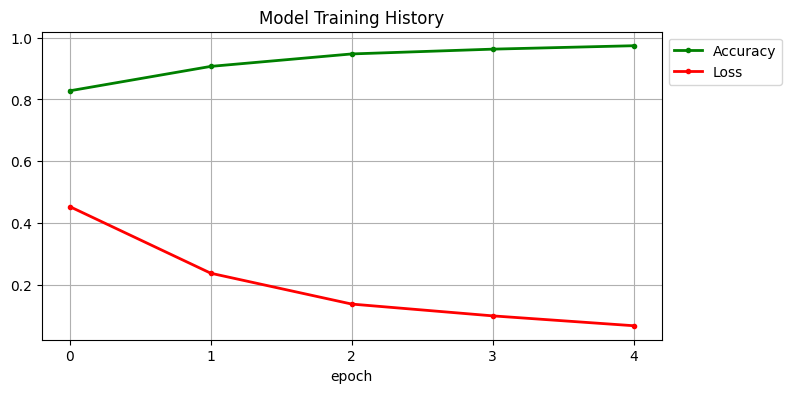

In [9]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Model Classification Report

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 [==============================] - 81s 2s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.99      0.87       300
           1       0.97      0.64      0.77       306
           2       0.93      1.00      0.96       405
           3       1.00      0.95      0.98       300

    accuracy                           0.90      1311
   macro avg       0.92      0.90      0.89      1311
weighted avg       0.92      0.90      0.90      1311



Model Confusion Plot

In [17]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[297   3   0   0]
 [ 84 197  25   0]
 [  0   0 405   0]
 [  5   4   5 286]]


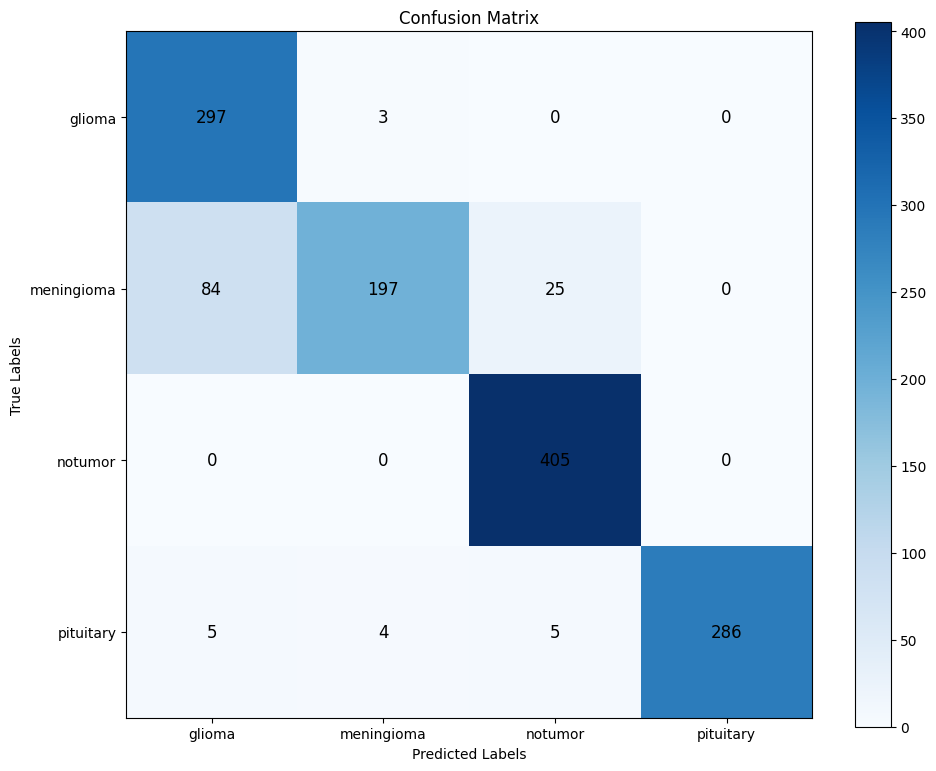

In [18]:
import matplotlib.pyplot as plt
import numpy as np

class_names = sorted(os.listdir(train_dir))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(conf_matrix, cmap="Blues")

# Add text manually (THIS IS THE KEY)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(
            j, i,
            conf_matrix[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=12
        )

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_title("Confusion Matrix")

plt.colorbar(im)
plt.tight_layout()
plt.show()


Roc Curve Plot

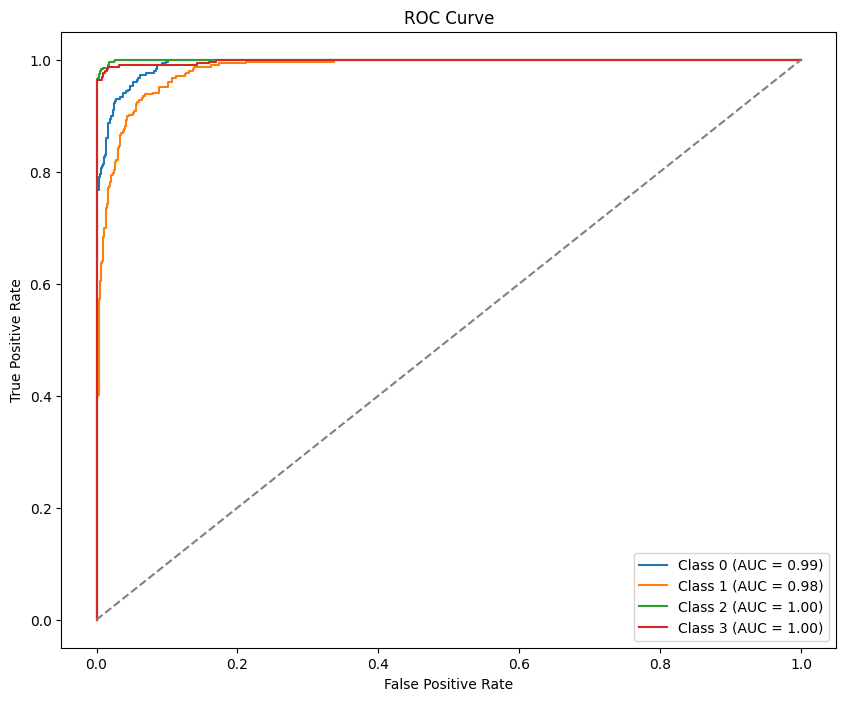

In [19]:
# ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

Save & Load Model

In [28]:
# model.save('model.h5')
model.save("models/model.keras", save_format="keras")

In [29]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('models/model.keras')


MRI Tumor Detection System

In [30]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

def detect_and_display(img_path, model, image_size=128):
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine class
        result = "No Tumor" if class_labels[predicted_class_index] == 'notumor' else f"Tumor: {class_labels[predicted_class_index]}"

        # Display image
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


1/1 [==============================] - 0s 372ms/step


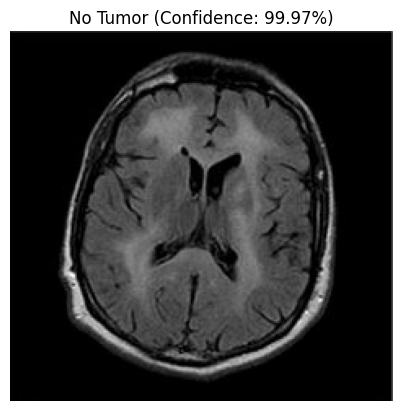

In [31]:
# Example usage
image_path = 'C:/Users/Apollo Gadget/Documents/Meem/Project/ML/Brain Tumor Detection Using Deep Learning/MRI Images/Testing/notumor/Te-no_0023.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 [==============================] - 0s 152ms/step


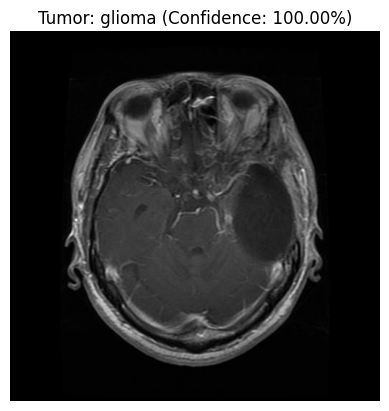

In [32]:
# Example usage
image_path = 'C:/Users/Apollo Gadget/Documents/Meem/Project/ML/Brain Tumor Detection Using Deep Learning/MRI Images/Testing/glioma/Te-gl_0015.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 [==============================] - 0s 233ms/step


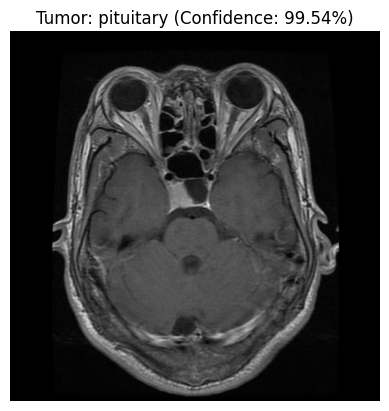

In [33]:
# Example usage
image_path = 'C:/Users/Apollo Gadget/Documents/Meem/Project/ML/Brain Tumor Detection Using Deep Learning/MRI Images/Testing/pituitary/Te-pi_0034.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)